In [590]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split




# 1. REGULAR

In [591]:
df = pd.read_csv("../data/raw_merged_2.csv")

In [592]:
df.head()

,Unnamed: 0,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
0,0,1960.0,221.559849,1954.311321,89.715075,532.147504,NaN,NaN,678.755833,NaN,NaN
1,1,1961.0,209.693206,2155.449969,75.965501,545.657512,NaN,NaN,633.084167,NaN,1020.0
2,2,1962.0,202.281031,2330.477365,71.061685,563.423009,NaN,NaN,645.143333,NaN,1020.0
3,3,1963.0,203.219451,2508.474307,74.468154,604.536855,NaN,NaN,645.950833,NaN,1020.0
4,4,1964.0,229.979246,2734.930090,85.661107,645.873376,NaN,NaN,969.753333,NaN,1020.0


In [593]:
df.drop(labels=['Unnamed: 0'], axis=1, inplace=True)

In [594]:
df.head()

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
0,1960.0,221.559849,1954.311321,89.715075,532.147504,NaN,NaN,678.755833,NaN,NaN
1,1961.0,209.693206,2155.449969,75.965501,545.657512,NaN,NaN,633.084167,NaN,1020.0
2,1962.0,202.281031,2330.477365,71.061685,563.423009,NaN,NaN,645.143333,NaN,1020.0
3,1963.0,203.219451,2508.474307,74.468154,604.536855,NaN,NaN,645.950833,NaN,1020.0
4,1964.0,229.979246,2734.930090,85.661107,645.873376,NaN,NaN,969.753333,NaN,1020.0


In [595]:
df.dtypes

Year      float64
GDP       float64
CHE       float64
CHN       float64
ZAF       float64
EXP       float64
FDI       float64
COP       float64
DEBT      float64
PRECIP    float64
dtype: object

Text(0.5, 1.0, 'Data distribution')

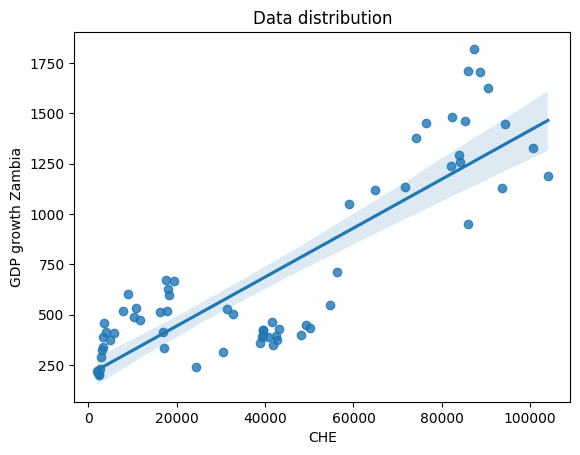

In [596]:
sns.regplot(x=df['CHE'], y=df['GDP'])
plt.xlabel('CHE')
plt.ylabel('GDP growth Zambia')
plt.title('Data distribution')

In [597]:
df.fillna(df.mean(), inplace=True)


,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
0,1960.0,221.559849,1954.311321,89.715075,532.147504,5.716680e+09,3.481361,678.755833,123.888918,1020.0
1,1961.0,209.693206,2155.449969,75.965501,545.657512,5.716680e+09,3.481361,633.084167,123.888918,1020.0
2,1962.0,202.281031,2330.477365,71.061685,563.423009,5.716680e+09,3.481361,645.143333,123.888918,1020.0
3,1963.0,203.219451,2508.474307,74.468154,604.536855,5.716680e+09,3.481361,645.950833,123.888918,1020.0
4,1964.0,229.979246,2734.930090,85.661107,645.873376,5.716680e+09,3.481361,969.753333,123.888918,1020.0
...,...,...,...,...,...,...,...,...,...,...
61,2021.0,1127.160779,93664.773670,12887.435724,6828.756246,1.153788e+10,1.784078,9317.050000,133.551637,1020.0
62,2022.0,1447.123101,94394.510680,12970.605641,6534.248678,1.172209e+10,-0.223287,8822.365833,103.673946,1020.0
63,2023.0,1330.727806,100623.549627,12951.178240,6034.272090,1.126453e+10,2.324653,8490.290833,110.675742,1020.0
64,2024.0,1187.109434,103998.186686,13303.148154,6267.186814,8.851528e+09,9.324378,9142.140000,114.201909,1020.0


In [598]:
df_norm = (df-df.min())/(df.max()-df.min())
df_norm.head()
df = df_norm


In [599]:
df.head()

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
0,0.000000,0.011912,0.000000,0.001410,0.000000,0.447512,0.420302,0.004903,0.267155,NaN
1,0.015385,0.004580,0.001971,0.000371,0.001665,0.447512,0.420302,0.000000,0.267155,NaN
2,0.030769,0.000000,0.003686,0.000000,0.003855,0.447512,0.420302,0.001295,0.267155,NaN
3,0.046154,0.000580,0.005431,0.000257,0.008922,0.447512,0.420302,0.001381,0.267155,NaN
4,0.061538,0.017114,0.007650,0.001103,0.014016,0.447512,0.420302,0.036146,0.267155,NaN


In [600]:
# X_train, X_test, Y_train, Y_test = train_test_split(df[['CHE']], df[['GDP' ]], test_size=0.20, random_state=42)
X = df[['CHE']]
y = df[['GDP']]
split_point = int(len(df) * 0.8)
X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]


In [601]:
y_train.isna().sum()

GDP    0
dtype: int64

In [602]:
model = LinearRegression()

In [603]:
# Train model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [604]:
print("Intercept: ", model.intercept_)
print("Coefficients: ", model.coef_)


Intercept:  [0.03897891]
Coefficients:  [[0.6095455]]


In [605]:
# Make prediction

y_pred = model.predict(X_test)

In [606]:
from sklearn.metrics import mean_squared_error, r2_score
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared:", r2_score(y_test, y_pred))

Mean Squared Error: 0.05192734681947331
R-squared: -0.5843054204195737


In [607]:
prediction = model.predict(pd.DataFrame({'CHE': [1900]}))
prediction


array([[1158.17542449]])

In [608]:
df.tail()

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
61,0.938462,0.571465,0.898736,0.968583,0.776027,0.983053,0.259612,0.932334,0.291484,NaN
62,0.953846,0.769163,0.905887,0.974868,0.739730,1.000000,0.069564,0.879223,0.216255,NaN
63,0.969231,0.697245,0.966930,0.973400,0.678110,0.957905,0.310791,0.843571,0.233885,NaN
64,0.984615,0.608506,1.000000,1.000000,0.706816,0.735913,0.973490,0.913555,0.242764,NaN
65,1.000000,0.305759,0.381151,0.193433,0.376905,0.447512,0.420302,1.000000,0.267155,NaN


# 2 [TIME SERIES](lhttps://www.geeksforgeeks.org/data-science/time-series-regression/)

In [609]:
df.set_index('Year', inplace=True)

In [610]:
df.head(3)

,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
Year,,,,,,,,,
0.000000,0.011912,0.000000,0.001410,0.000000,0.447512,0.420302,0.004903,0.267155,NaN
0.015385,0.004580,0.001971,0.000371,0.001665,0.447512,0.420302,0.000000,0.267155,NaN
0.030769,0.000000,0.003686,0.000000,0.003855,0.447512,0.420302,0.001295,0.267155,NaN


In [611]:
# df_norm = (df-df.min())/(df.max()-df.min())
# df_norm.head()
# df = df_norm


In [612]:
# df_norm.head()

In [613]:
# df = df_norm

In [614]:
df.head()

,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
Year,,,,,,,,,
0.000000,0.011912,0.000000,0.001410,0.000000,0.447512,0.420302,0.004903,0.267155,NaN
0.015385,0.004580,0.001971,0.000371,0.001665,0.447512,0.420302,0.000000,0.267155,NaN
0.030769,0.000000,0.003686,0.000000,0.003855,0.447512,0.420302,0.001295,0.267155,NaN
0.046154,0.000580,0.005431,0.000257,0.008922,0.447512,0.420302,0.001381,0.267155,NaN
0.061538,0.017114,0.007650,0.001103,0.014016,0.447512,0.420302,0.036146,0.267155,NaN


In [615]:
df.drop(labels=['PRECIP'], axis=1, inplace=True)

In [616]:
df['Lag1'] = df['GDP'].shift(1)
df['Lag2'] = df['GDP'].shift(2)
df = df.dropna()
df[['GDP', 'Lag1', 'Lag2']].head()

,GDP,Lag1,Lag2
Year,,,
0.030769,0.000000,0.004580,0.011912
0.046154,0.000580,0.000000,0.004580
0.061538,0.017114,0.000580,0.000000
0.076923,0.052609,0.017114,0.000580
0.092308,0.075842,0.052609,0.017114


In [617]:
df.head()

,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,Lag1,Lag2
Year,,,,,,,,,,
0.030769,0.000000,0.003686,0.000000,0.003855,0.447512,0.420302,0.001295,0.267155,0.004580,0.011912
0.046154,0.000580,0.005431,0.000257,0.008922,0.447512,0.420302,0.001381,0.267155,0.000000,0.004580
0.061538,0.017114,0.007650,0.001103,0.014016,0.447512,0.420302,0.036146,0.267155,0.000580,0.000000
0.076923,0.052609,0.008927,0.002086,0.018792,0.447512,0.420302,0.070834,0.267155,0.017114,0.000580
0.092308,0.075842,0.010687,0.002528,0.023368,0.447512,0.420302,0.096458,0.267155,0.052609,0.017114


In [618]:
# split data into training 
X = df[['Lag1', 'Lag2']]
y = df['GDP']

split_point = int(len(df) * 0.8)
X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]

X_train.head()
X_test.head()

,Lag1,Lag2
Year,,
0.815385,0.931621,0.878988
0.830769,1.000000,0.931621
0.846154,0.930036,1.000000
0.861538,0.675712,0.930036
0.876923,0.640620,0.675712


In [619]:
# TRAIN MODEL
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [620]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept: ", model.intercept_)
print("Coefficients: ", model.coef_)


Intercept:  0.0035748806597140914
Coefficients:  [1.05608666 0.01731024]


In [621]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual': y_test.head().values,
    'Predicted': y_pred[:5]
})

In [622]:
comparison.head()

,Actual,Predicted
0,1.000000,1.002662
1,0.930036,1.075788
2,0.675712,1.003083
3,0.640620,0.733284
4,0.791618,0.691822


In [623]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print("R-squared:", r2_score(y_test, y_pred))


Mean Squared Error: 0.033585057563970615
R-squared: -0.08688965332601106


In [624]:
print("actual: ", y_test, "predicted: ", y_pred)

actual:  Year
0.815385    1.000000
0.830769    0.930036
0.846154    0.675712
0.861538    0.640620
0.876923    0.791618
0.892308    0.779529
0.907692    0.652917
0.923077    0.463017
0.938462    0.571465
0.953846    0.769163
0.969231    0.697245
0.984615    0.608506
1.000000    0.305759
Name: GDP, dtype: float64 predicted:  [1.00266236 1.07578811 1.00308344 0.73328393 0.69182237 0.85068169
 0.84052814 0.70660552 0.50386258 0.61510595 0.82576973 0.75323997
 0.65827907]


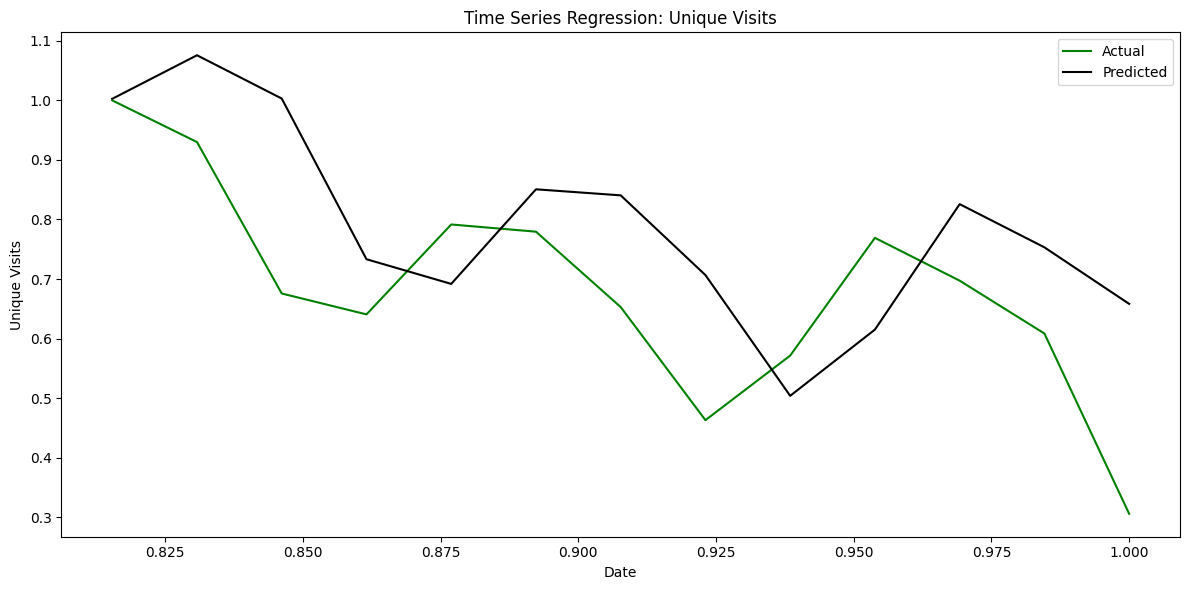

In [625]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual', color='green')
plt.plot(y_test.index, y_pred, label='Predicted', color='black')
plt.title('Time Series Regression: Unique Visits')
plt.xlabel('Date')
plt.ylabel('Unique Visits')
plt.legend()
plt.tight_layout()
plt.show()